In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [20]:
local_csv = "winequality-red.csv"
df = pd.read_csv(local_csv, sep=";")

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [21]:
def categorize_quality(quality):
    if quality <= 4:
        return 0  
    elif quality <= 6:
        return 1 
    else:
        return 2 

df["label"] = df["quality"].apply(categorize_quality)

print("\nConteo de clases en 'label':")
print(df["label"].value_counts())


Conteo de clases en 'label':
label
1    1319
2     217
0      63
Name: count, dtype: int64


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X = df.drop(["quality", "label"], axis=1)
y = df["label"]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(f"\nResultados con k={k}")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("Reporte de clasificación:\n", classification_report(y_test, y_pred))


Resultados con k=5
Accuracy: 0.81875
Matriz de confusión:
 [[  0  13   0]
 [  1 243  20]
 [  0  24  19]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.87      0.92      0.89       264
           2       0.49      0.44      0.46        43

    accuracy                           0.82       320
   macro avg       0.45      0.45      0.45       320
weighted avg       0.78      0.82      0.80       320



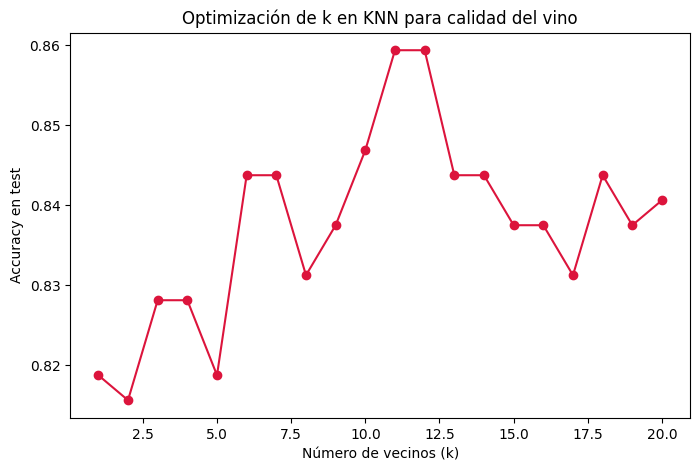

Mejor k: 11 con accuracy = 0.859


In [24]:
scores = []
k_values = range(1, 21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

plt.figure(figsize=(8,5))
plt.plot(k_values, scores, marker="o", color="crimson")
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Accuracy en test")
plt.title("Optimización de k en KNN para calidad del vino")
plt.show()

best_k = k_values[np.argmax(scores)]
print(f"Mejor k: {best_k} con accuracy = {max(scores):.3f}")

In [25]:
def predict_wine_quality(features):
    model = KNeighborsClassifier(n_neighbors=best_k)
    model.fit(X_train, y_train)

    scaled_features = scaler.transform([features])
    prediction = model.predict(scaled_features)[0]

    labels = {0: "Baja calidad 🍷", 1: "Calidad media 🍷", 2: "Alta calidad 🍷"}
    return f"Este vino probablemente sea de {labels[prediction]}"

# Ejemplo de predicción:
print(
    predict_wine_quality(
        [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]
    )
)

Este vino probablemente sea de Calidad media 🍷


c:\Users\sm730\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
